In [113]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris=load_iris(as_frame=True)

X = iris.data.iloc[:,2:].to_numpy()
y = iris.target == 2

pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1 , random_state=42))
])
pipline.fit(X,y)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


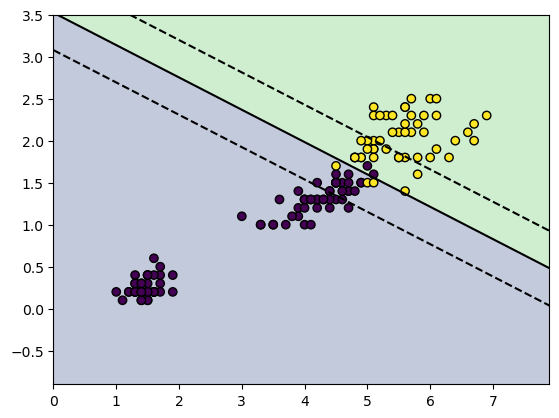

In [114]:
import numpy as np
import matplotlib.pyplot as plt

x0min , x0max = X[:,0].min() - 1 , X[:,0].max() + 1
x1min , x1max = X[:,1].min() - 1 , X[:,1].max() + 1

xx,yy = np.meshgrid(
    np.linspace(x0min , x0max , 500) ,
    np.linspace(x1min , x1max , 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]
z = pipline.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx, yy, z, alpha=0.3) # 결정영역
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

decison = pipline.decision_function(grid)
decison = decison.reshape(xx.shape)

plt.contour(
    xx,yy,decison,levels = [-1,0,1] ,
    linestyles = ['--','-','--'],
    colors = 'k'
)

plt.show()

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.96      0.90      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



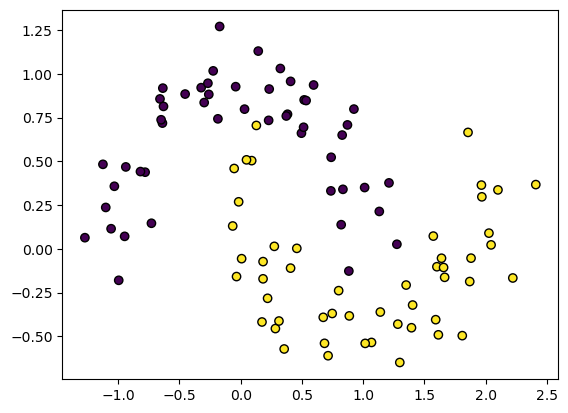

In [115]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier , LogisticRegression

X,y = make_moons(n_samples=100, noise=0.15, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('model', SGDClassifier(random_state=42)),
])

pipeline.fit(X,y)
y_pred = pipeline.predict(X)
print(classification_report(y,y_pred))

In [116]:
from sklearn.svm import SVC

pipeline = Pipeline([
    ('scaler' , StandardScaler()) ,
    ('svc' , SVC(kernel='poly',degree=3 , coef0=1 ,C=5))
])

pipeline.fit(X,y)
predict = pipeline.predict(X)
print(classification_report(y,predict))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       0.98      0.98      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



In [282]:
from sklearn.datasets import load_wine
from sklearn.svm import SVC , LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

wine = load_wine(as_frame=True)
X = wine.data.to_numpy()
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42 , stratify=y)

pipeline = Pipeline([
    ('scaler' , StandardScaler()) ,
    ('svc' , SVC(kernel='poly',degree=3 , coef0=1 ,C=5))
])

pipeline.fit(X_train, y_train)
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

from sklearn.model_selection import cross_val_score
# 전체 데이터(X, y)에 대해 5-폴드 교차 검증 수행
scores = cross_val_score(pipeline, X, y, cv=5)
print(f"교차 검증 평균 점수: {scores.mean():.5f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

교차 검증 평균 점수: 0.97222


In [286]:
from sklearn.linear_model import SGDClassifier , LogisticRegression
wine = load_wine(as_frame=True)

X = wine.data.to_numpy()
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , stratify=y , random_state=42)

pipeline = Pipeline([
    ('scaler' , StandardScaler()) ,
    ('model' , LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)
predict = pipeline.predict(X_test)
print(classification_report(y_test,predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

